In [1]:
!uv pip install matplotlib seaborn

Using Python 3.12.3 environment at: C:\Users\mngtr\Transformer_math_project\grokking-carries\.venv
Checked 2 packages in 8ms


In [2]:
# Загрузка модели

import os
import sys
import torch
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from grokking_carries.config import ModelConfig
from grokking_carries.model.transformer import GrokkingCarriesTransformer
from grokking_carries.data.tokenizer import MathTokenizer

model_cfg = ModelConfig()
model = GrokkingCarriesTransformer(model_cfg)
tokenizer = MathTokenizer()

save_dir = os.path.abspath(os.path.join(project_root, "src", "grokking_carries", "model"))
save_path = os.path.join(save_dir, "grokking_model_5_epochs.pth")

model.load_state_dict(torch.load(save_path, map_location=model_cfg.device, weights_only=True))
model.to(model_cfg.device)
model.eval()

print("Модель загружена.")

# Примеры для анализа

# Корректный пример
clean_prompt = "0 0 5 0 2 - 0 0 0 1 9 ="
clean_target = "<b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0"

# Пример, на котором модель ошибается
corrupted_prompt = "6 9 0 1 2 - 3 4 6 8 0 ="
corrupted_target = "<b0> 2 <b1> 3 <b1> 3 <b0> 4 <b0> 3"

def prepare_tensor(prompt: str, target: str, tokenizer, device):
    full_text = f"{prompt} {target}"
    tokens = tokenizer.encode(full_text, from_split=True)
    return torch.tensor([tokens], dtype=torch.long).to(device), tokens

clean_tensor, clean_tokens = prepare_tensor(clean_prompt, clean_target, tokenizer, model_cfg.device)
str_tokens = [tokenizer.i2v[t] for t in clean_tokens] # Строковые токены для осей графиков

print(f"Исследуем последовательность из {len(str_tokens)} токенов.")

Модель загружена.
Исследуем последовательность из 22 токенов.


In [3]:
# Извлечение матриц внимания

Матрицы внимания извлечены. В кэше 4 слоев.


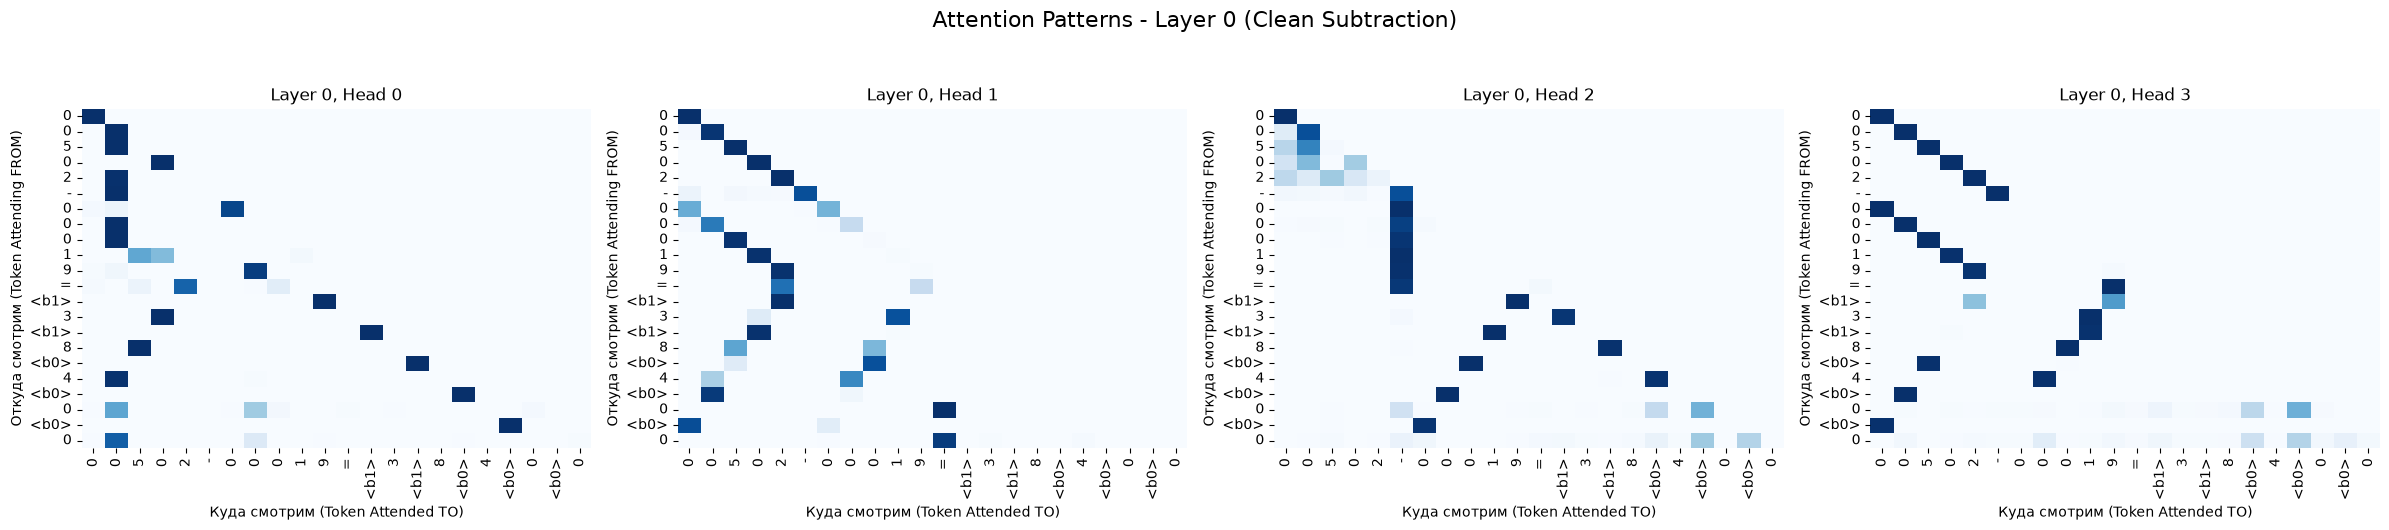

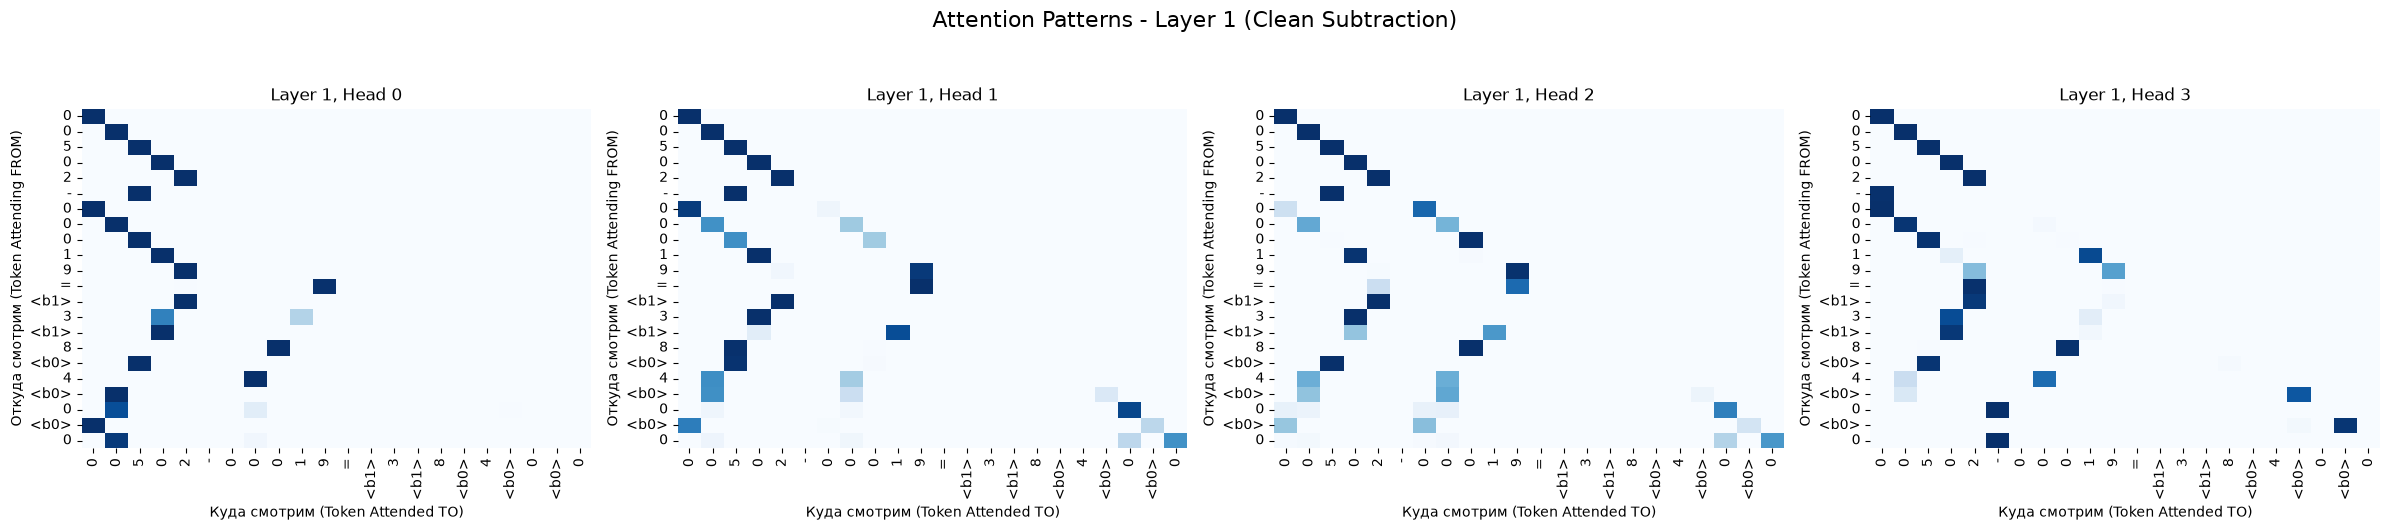

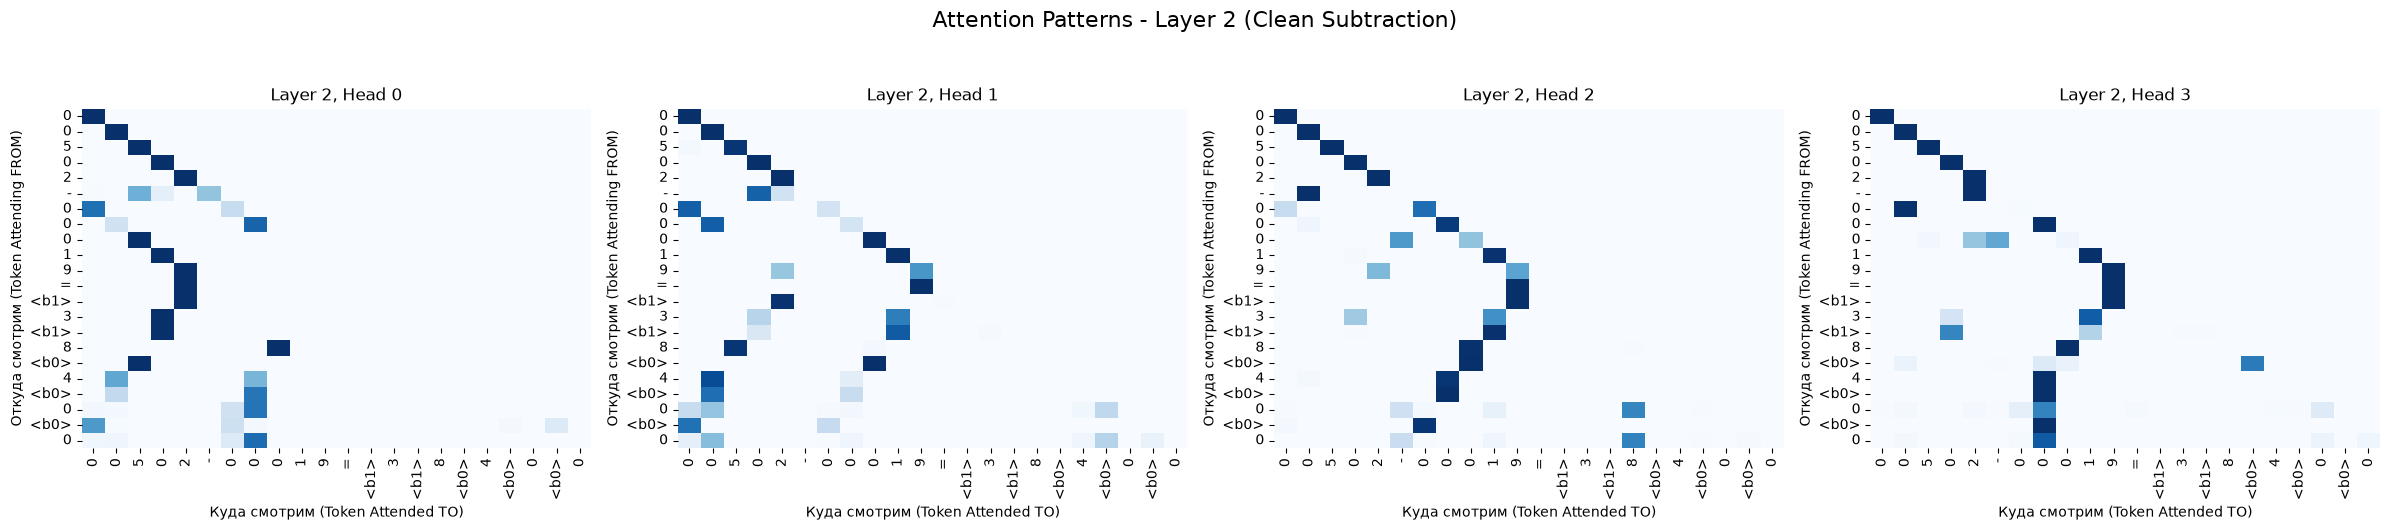

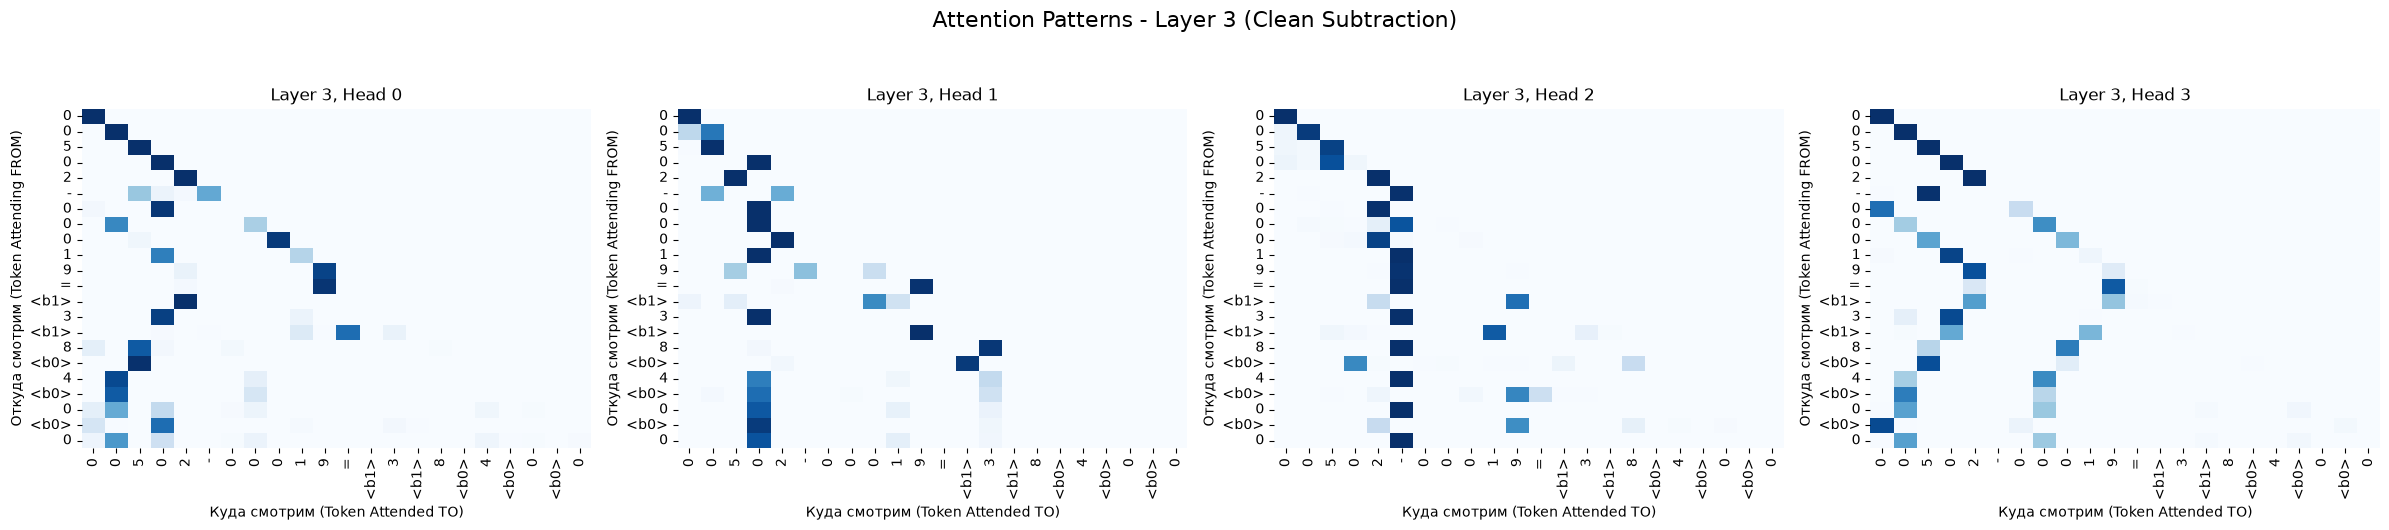

In [4]:
# Словарь для кэширования матриц внимания
cache = {}

# Функция для перехвата тензора
def save_attention_pattern_hook(tensor, hook_name):
    cache[hook_name] = tensor.detach().cpu()
    return tensor

hooks_to_add = []
for layer in range(model_cfg.n_layers):
    hook_name = f"blocks.{layer}.attn.hook_pattern"
    hooks_to_add.append((hook_name, save_attention_pattern_hook))

with model.hooks(fwd_hooks=hooks_to_add):
    _ = model(clean_tensor)

print(f"Матрицы внимания извлечены. В кэше {len(cache)} слоев.")

# Отрисовка визуализации
def plot_attention_layer(cache_dict, layer_idx: int, str_tokens: list, title_suffix=""):
    hook_name = f"blocks.{layer_idx}.attn.hook_pattern"
    pattern = cache_dict[hook_name][0] 
    n_heads = pattern.shape[0]
    
    fig, axes = plt.subplots(1, n_heads, figsize=(6 * n_heads, 5))
    if n_heads == 1:
        axes = [axes]
        
    for head_idx in range(n_heads):
        ax = axes[head_idx]
        head_pattern = pattern[head_idx].numpy()
        
        sns.heatmap(
            head_pattern, 
            cmap="Blues", 
            cbar=False, 
            xticklabels=str_tokens, 
            yticklabels=str_tokens,
            ax=ax
        )
        ax.set_title(f"Layer {layer_idx}, Head {head_idx}")
        ax.tick_params(axis='x', rotation=90)
        ax.tick_params(axis='y', rotation=0)
        ax.set_xlabel("Куда смотрим (Token Attended TO)")
        ax.set_ylabel("Откуда смотрим (Token Attending FROM)")
        
    plt.suptitle(f"Attention Patterns - Layer {layer_idx} {title_suffix}", y=1.05, fontsize=16)
    plt.tight_layout()
    plt.show()

for layer in range(model_cfg.n_layers):
    plot_attention_layer(cache, layer, str_tokens, title_suffix="(Clean Subtraction)")

In [5]:
# Проанализируем что будет происходить при поочерёдном отключении голов

In [6]:
prompt_len = len(tokenizer.encode(clean_prompt, from_split=True))
start_idx = prompt_len - 1 

def get_ablation_hook(head_idx_to_ablate):
    def custom_zero_ablation_hook(z_tensor, hook):
        ablated_z = z_tensor.clone()
        # Выключаем строго заданную голову
        ablated_z[:, :, head_idx_to_ablate, :] = 0.0
        return ablated_z
    return custom_zero_ablation_hook

print("Отключаем головы по очереди")
print(f"Промпт:   {clean_prompt}")
print(f"Ожидали:  {clean_target}\n")
print("-" * 50)

broken_count = 0

# Проходимся по всем слоям и всем головам
for layer in range(model_cfg.n_layers):
    for head in range(model_cfg.n_heads):
        hook_name = f"blocks.{layer}.attn.hook_z"
        
        with torch.no_grad():
            with model.hooks(fwd_hooks=[(hook_name, get_ablation_hook(head))]):
                logits = model(clean_tensor)
                preds = torch.argmax(logits[0, start_idx:-1, :], dim=-1).tolist()
                got = tokenizer.decode(preds).strip()
                
                # Проверяем, сломался ли ответ
                if got == clean_target.strip():
                    status = "Ответ корректен"
                else:
                    status = "Ответ сломался"
                    broken_count += 1
                
                print(f"Без Layer {layer}, Head {head} | {status} | Вывод: {got}")

print("-" * 50)
print(f"Из {model_cfg.n_layers * model_cfg.n_heads} голов отключение одной сломало ответ в {broken_count} случаях.")

Отключаем головы по очереди
Промпт:   0 0 5 0 2 - 0 0 0 1 9 =
Ожидали:  <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0

--------------------------------------------------
Без Layer 0, Head 0 | Ответ сломался | Вывод: <b1> 3 <b1> 8 <b0> 5 <b0> 0 <b0> 0
Без Layer 0, Head 1 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 0, Head 2 | Ответ сломался | Вывод: <b1> 3 <b1> 1 <b0> 4 <b0> 0 <b0> 0
Без Layer 0, Head 3 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 1, Head 0 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 1, Head 1 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 1, Head 2 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 1, Head 3 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 2, Head 0 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 2, Head 1 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 2, Head 2 | О

In [7]:
# По результатам имеем:
# Layer 0, Head 0 отвечала за исполнение операции заёма
# Layer 0, Head 2 отвечала за арифметику вычисления разряда
# Layer 3, Head 2 отвечала за генерацию токена исполняемой операции